# Experiment 4: Retraining Strategies

This notebook explores different retraining strategies to improve hedge robustness for Snowball options. We'll compare single-shot training vs. incremental retraining approaches and test performance on historical data.

## Objectives
- Compare different retraining strategies (frequent, batch, single-shot)
- Test performance on real historical market data
- Analyze hedge paths and cumulative PnL evolution
- Understand the trade-offs between training approaches

In [1]:
# Import all necessary libraries
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# PfHedge imports
from pfhedge.instruments import BrownianStock, Snowball
from pfhedge.instruments.primary.fixed import FixedStock
from pfhedge.nn.modules.hedger import Hedger
from pfhedge.nn.modules.loss import ExpectedShortfall
from pfhedge.nn.modules.mlp import MultiLayerPerceptron

# Set random seed for reproducibility
torch.manual_seed(42)
print("Retraining strategies experiment loaded successfully!")

Retraining strategies experiment loaded successfully!


In [2]:
# ==== 全局变量和函数定义 ====
# 训练参数
train_seed = 888
n_paths = 1000
total_n_epochs = 50

# Market setup
init_state = 100.0
dt = 1 / 250
sigma = 0.21
mu = 0.0
cost = 1e-4
obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]

loss = ExpectedShortfall(0.5)

features = [
    "log_moneyness",
    "expiry_time",
    "volatility",
    "knocked_in",
    "knockin_barrier_to_strike",
    "prev_hedge",
]

def create_snowball(ki_barrier, underlier=None, knocked_in=False, offset=0):
    if underlier is None:
        underlier = BrownianStock(sigma=sigma, mu=mu, dt=dt, cost=cost)
    obs = [d - offset for d in obs_days if d >= offset]
    ko_coupons = [0.2 * d / 250 for d in obs_days if d >= offset]
    return Snowball(
        underlier=underlier,
        notional=100,
        init_spot=init_state,
        strike=100.0,
        maturity=obs[-1] * dt if obs else dt,
        knockin_barrier=ki_barrier,
        observations=[d * dt for d in obs],
        knockout_barriers=[100.0] * len(obs),
        knockout_coupons=ko_coupons,
        no_touch_coupon=0.05,
        is_knocked_in=knocked_in,
    )

def create_hedger():
    return Hedger(
        MultiLayerPerceptron(n_layers=4, n_units=[32, 32, 32, 32]),
        features,
        criterion=loss,
    )

def retrain_frequent(n_epochs_per_retrain, n_retrains):
    torch.manual_seed(train_seed)
    history = []
    hedger = create_hedger()
    ki_barriers = torch.rand(n_retrains) * 20 + 70
    progress = tqdm(range(n_retrains), desc="Frequent Retraining")
    for i in progress:
        derivative = create_snowball(ki_barriers[i].item())
        h = hedger.fit(
            derivative,
            n_epochs=n_epochs_per_retrain,
            n_paths=n_paths,
            init_state=(init_state,),
            verbose=False,
        )
        progress.set_description(f"Retrain {i+1}/{n_retrains}, Loss={h[-1]:.4f}")
        history.extend(h)
    return hedger, history

def retrain_batch(n_epochs_per_retrain, n_retrains):
    torch.manual_seed(train_seed)
    history = []
    hedger = create_hedger()
    ki_barriers = torch.rand(n_retrains) * 20 + 70
    progress = tqdm(range(n_retrains), desc="Batch Retraining")
    for i in progress:
        derivative = create_snowball(ki_barriers[i].item())
        h = hedger.fit(
            derivative,
            n_epochs=n_epochs_per_retrain,
            n_paths=n_paths,
            init_state=(init_state,),
            verbose=False,
        )
        progress.set_description(f"Batch {i+1}/{n_retrains}, Loss={h[-1]:.4f}")
        history.extend(h)
    return hedger, history

def train_random_barrier():
    torch.manual_seed(train_seed)
    derivative = create_snowball(lambda x: torch.rand(x) * 20 + 70)
    hedger = create_hedger()
    history = hedger.fit(
        derivative, n_epochs=total_n_epochs, n_paths=n_paths, init_state=(init_state,)
    )
    return hedger, history

def train_fixed_barrier():
    torch.manual_seed(train_seed)
    derivative = create_snowball(80.0)
    features_fixed = [f for f in features if f != "knockin_barrier_to_strike"]
    hedger = Hedger(
        MultiLayerPerceptron(n_layers=4, n_units=[32, 32, 32, 32]),
        features_fixed,
        criterion=loss,
    )
    history = hedger.fit(
        derivative, n_epochs=total_n_epochs, n_paths=n_paths, init_state=(init_state,)
    )
    return hedger, history

def create_delta_hedge_strategy():
    """Create delta hedge strategy for comparison."""
    return "Delta Hedge", None

# ==== 执行策略训练 ====
print("Training different strategies...")
hedger_retrain_1, history_retrain_1 = retrain_frequent(1, total_n_epochs)
hedger_retrain_10, history_retrain_10 = retrain_batch(5, total_n_epochs // 5)
hedger_random, history_random = train_random_barrier()
hedger_fixed, history_fixed = train_fixed_barrier()

strategies = {
    "Frequent Retrain (1 epoch)": (hedger_retrain_1, history_retrain_1),
    "Batch Retrain (5 epochs)": (hedger_retrain_10, history_retrain_10),
    "Random Barrier": (hedger_random, history_random),
    "Fixed Barrier": (hedger_fixed, history_fixed),
    "Delta Hedge": create_delta_hedge_strategy(),
}
strategy_names = list(strategies.keys())

Training different strategies...


Frequent Retraining:   0%|          | 0/50 [00:00<?, ?it/s]

Loss=4.3565: 100%|██████████| 50/50 [02:21<00:00,  2.83s/it]


In [3]:
# PnL分析
test_ki_barriers = [75, 80, 85]
test_seed = 123
test_n_paths = 10000
init_spot = torch.tensor(init_state, requires_grad=True)

def test_hedger_pnl(hedger, ki_barrier):
    with torch.no_grad():
        torch.manual_seed(test_seed)
        derivative_test = create_snowball(ki_barrier)
        derivative_test.simulate(n_paths=test_n_paths, init_state=(init_spot,))
        option_pnl = -derivative_test.payoff()
        hedge_pnl = hedger.compute_portfolio(derivative_test)
        total_pnl = hedger.compute_pl(derivative_test)
        return (
            total_pnl.detach().numpy(),
            option_pnl.detach().numpy(),
            hedge_pnl.detach().numpy(),
            loss(total_pnl).detach().item()
        )

pnl_data, option_pnl_data, hedge_pnl_data, loss_data = {}, {}, {}, {}
hedgers_list = [strategies[name][0] for name in strategy_names]

for barrier in test_ki_barriers:
    results = []
    for i, hedger in enumerate(hedgers_list):
        if strategy_names[i] == "Delta Hedge":
            results.append((None, None, None, 0.0))
        else:
            pnl, opt_pnl, hdg_pnl, loss_val = test_hedger_pnl(hedger, barrier)
            results.append((pnl, opt_pnl, hdg_pnl, loss_val))
    pnl_data[barrier] = [r[0] for r in results]
    option_pnl_data[barrier] = [r[1] for r in results]
    hedge_pnl_data[barrier] = [r[2] for r in results]
    loss_data[barrier] = [r[3] for r in results]

In [4]:
def compute_delta_hedge(derivative, spots, mc_n_path=10000):
    def calc_pv(derivative, spot):
        with torch.no_grad():
            derivative.simulate(n_paths=mc_n_path, init_state=(spot,))
            return derivative.payoff().mean().item()
    def calc_delta(derivative, spot):
        with torch.no_grad():
            spot_up = spot * 1.01
            spot_down = spot * 0.99
            derivative.simulate(n_paths=mc_n_path, init_state=(spot_up,))
            pv_up = derivative.payoff().mean().item()
            derivative.simulate(n_paths=mc_n_path, init_state=(spot_down,))
            pv_down = derivative.payoff().mean().item()
            return (pv_up - pv_down) / (spot_up - spot_down)
    delta_hedging, pvs = [], []
    is_knocked_in = False
    is_knocked_out = False
    for i in range(len(spots)):
        current_derivative = create_snowball(80.0, offset=i, knocked_in=is_knocked_in)
        s = spots[i]
        if s <= 80:
            is_knocked_in = True
        if is_knocked_out or (i in obs_days and s > 100):
            is_knocked_out = True
            pvs.append(derivative.payoff().item())
            delta_hedging.append(0)
        else:
            pv = calc_pv(current_derivative, s)
            pvs.append(pv)
            delta = calc_delta(current_derivative, s)
            delta_hedging.append(delta)
    pvs.append(0)
    delta_hedging.append(0)
    return np.array(delta_hedging), np.array(pvs)

尝试读取文件: csi500.csv
文件是否存在: True
原始数据长度: 1210
处理后数据长度: 1145 (去掉最后65个点)
使用的时间范围: 20200311.0 到 20241127.0
Historical volatility: 0.210652
模拟的价格路径长度: 251


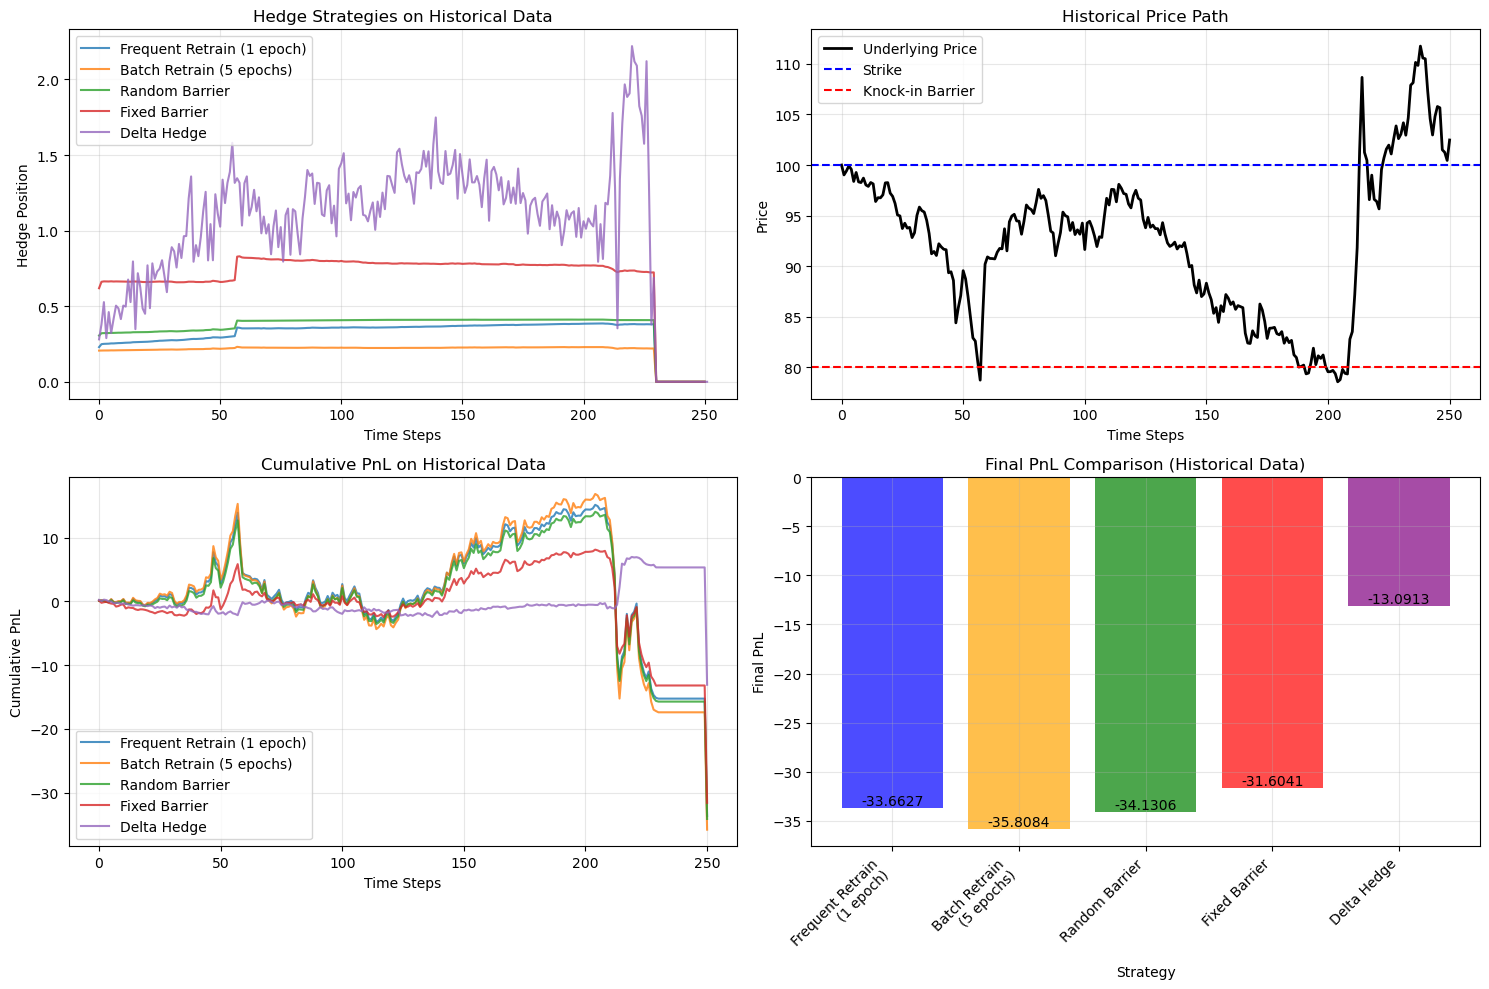


Historical Data Performance Summary:
----------------------------------------
Frequent Retrain (1 epoch): Final PnL = -33.662724
Batch Retrain (5 epochs): Final PnL = -35.808395
Random Barrier: Final PnL = -34.130591
Fixed Barrier: Final PnL = -31.604074
Delta Hedge: Final PnL = -13.091325


In [7]:
# 历史数据测试与可视化（使用与snowball_hedge.py完全相同的数据）

import os

# 1. 加载历史数据 - 使用与snowball_hedge.py完全相同的数据处理
csv_path = "csi500.csv"
print(f"尝试读取文件: {csv_path}")
print(f"文件是否存在: {os.path.exists(csv_path)}")

try:
    quotes = pd.read_csv(csv_path)
    print(f"原始数据长度: {len(quotes)}")
    
    # 使用与snowball_hedge.py完全相同的数据处理：去掉最后65个数据点
    series = torch.tensor(quotes["Close"].values, dtype=torch.float)[:-65]
    print(f"处理后数据长度: {len(series)} (去掉最后65个点)")
    
    # 显示使用的时间范围
    start_date = quotes.iloc[0]['Date']
    end_date = quotes.iloc[len(series)-1]['Date']
    print(f"使用的时间范围: {start_date} 到 {end_date}")
    
    fixed_stock = FixedStock(spots=list(series), cost=1e-4, dt=1/250)
    his_vol = fixed_stock.volatility
    print(f"Historical volatility: {his_vol:.6f}")
    
except Exception as e:
    print(f"Market data not available, using synthetic data. Error: {e}")
    series = torch.randn(1000).cumsum(0).exp()
    fixed_stock = FixedStock(spots=list(series), cost=1e-4, dt=1/250)
    his_vol = 0.2

# 2. 生成测试路径
init_spot = torch.tensor(init_state, requires_grad=True)
test_derivative = create_snowball(80.0, underlier=fixed_stock)
test_derivative.simulate(n_paths=1, init_state=(init_spot,))
spots = test_derivative.ul().spot.squeeze().detach().numpy()

print(f"模拟的价格路径长度: {len(spots)}")

# 3. 计算各策略的hedge路径和PnL
hedge_paths, pnl_paths = {}, {}
for name, (hedger, _) in strategies.items():
    try:
        if name == "Delta Hedge":
            delta_hedge_positions, delta_pvs = compute_delta_hedge(test_derivative, spots)
            hedge_paths[name] = delta_hedge_positions

            # 保证长度匹配
            min_len = min(len(delta_hedge_positions), len(spots))
            delta_hedge_positions = delta_hedge_positions[:min_len]
            delta_pvs = delta_pvs[:min_len]
            spots_adj = spots[:min_len]

            from pfhedge.nn.functional import cum_pl
            delta_hedge_pnl = cum_pl(
                torch.tensor(spots_adj).unsqueeze(0).unsqueeze(0),
                torch.tensor(delta_hedge_positions).unsqueeze(0).unsqueeze(0),
                cost=[cost],
                payoff=test_derivative.payoff(),
            ).squeeze().detach().numpy()
            pnl_paths[name] = delta_hedge_pnl - delta_pvs
        else:
            hedge = hedger.compute_hedge(test_derivative).squeeze()
            pnl = hedger.compute_cum_pl(test_derivative).squeeze()
            hedge_paths[name] = hedge.detach().numpy()
            delta_pvs = delta_pvs[:min_len]
            pnl_paths[name] = pnl.detach().numpy() - delta_pvs
    except Exception as e:
        print(f"Error computing hedge for {name}: {e}")

# 4. 可视化
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
for name, hedge in hedge_paths.items():
    plt.plot(hedge, label=name, alpha=0.8)
plt.xlabel("Time Steps")
plt.ylabel("Hedge Position")
plt.title("Hedge Strategies on Historical Data")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(spots, label="Underlying Price", color='black', linewidth=2)
plt.axhline(y=100, color='blue', linestyle='--', label='Strike')
plt.axhline(y=80, color='red', linestyle='--', label='Knock-in Barrier')
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.title("Historical Price Path")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
for name, pnl in pnl_paths.items():
    plt.plot(pnl, label=name, alpha=0.8)
plt.xlabel("Time Steps")
plt.ylabel("Cumulative PnL")
plt.title("Cumulative PnL on Historical Data")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
final_pnls = [pnl[-1] for pnl in pnl_paths.values()]
strategy_names_short = list(pnl_paths.keys())
colors = ['blue', 'orange', 'green', 'red', 'purple']
bars = plt.bar(range(len(final_pnls)), final_pnls,
               color=colors[:len(final_pnls)], alpha=0.7)
plt.xlabel("Strategy")
plt.ylabel("Final PnL")
plt.title("Final PnL Comparison (Historical Data)")
plt.xticks(range(len(strategy_names_short)),
           [name.replace(' (', '\n(') for name in strategy_names_short],
           rotation=45, ha='right')
plt.grid(True, alpha=0.3)
for bar, value in zip(bars, final_pnls):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{value:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print("\nHistorical Data Performance Summary:")
print("-" * 40)
for name, pnl in pnl_paths.items():
    print(f"{name}: Final PnL = {pnl[-1]:.6f}")

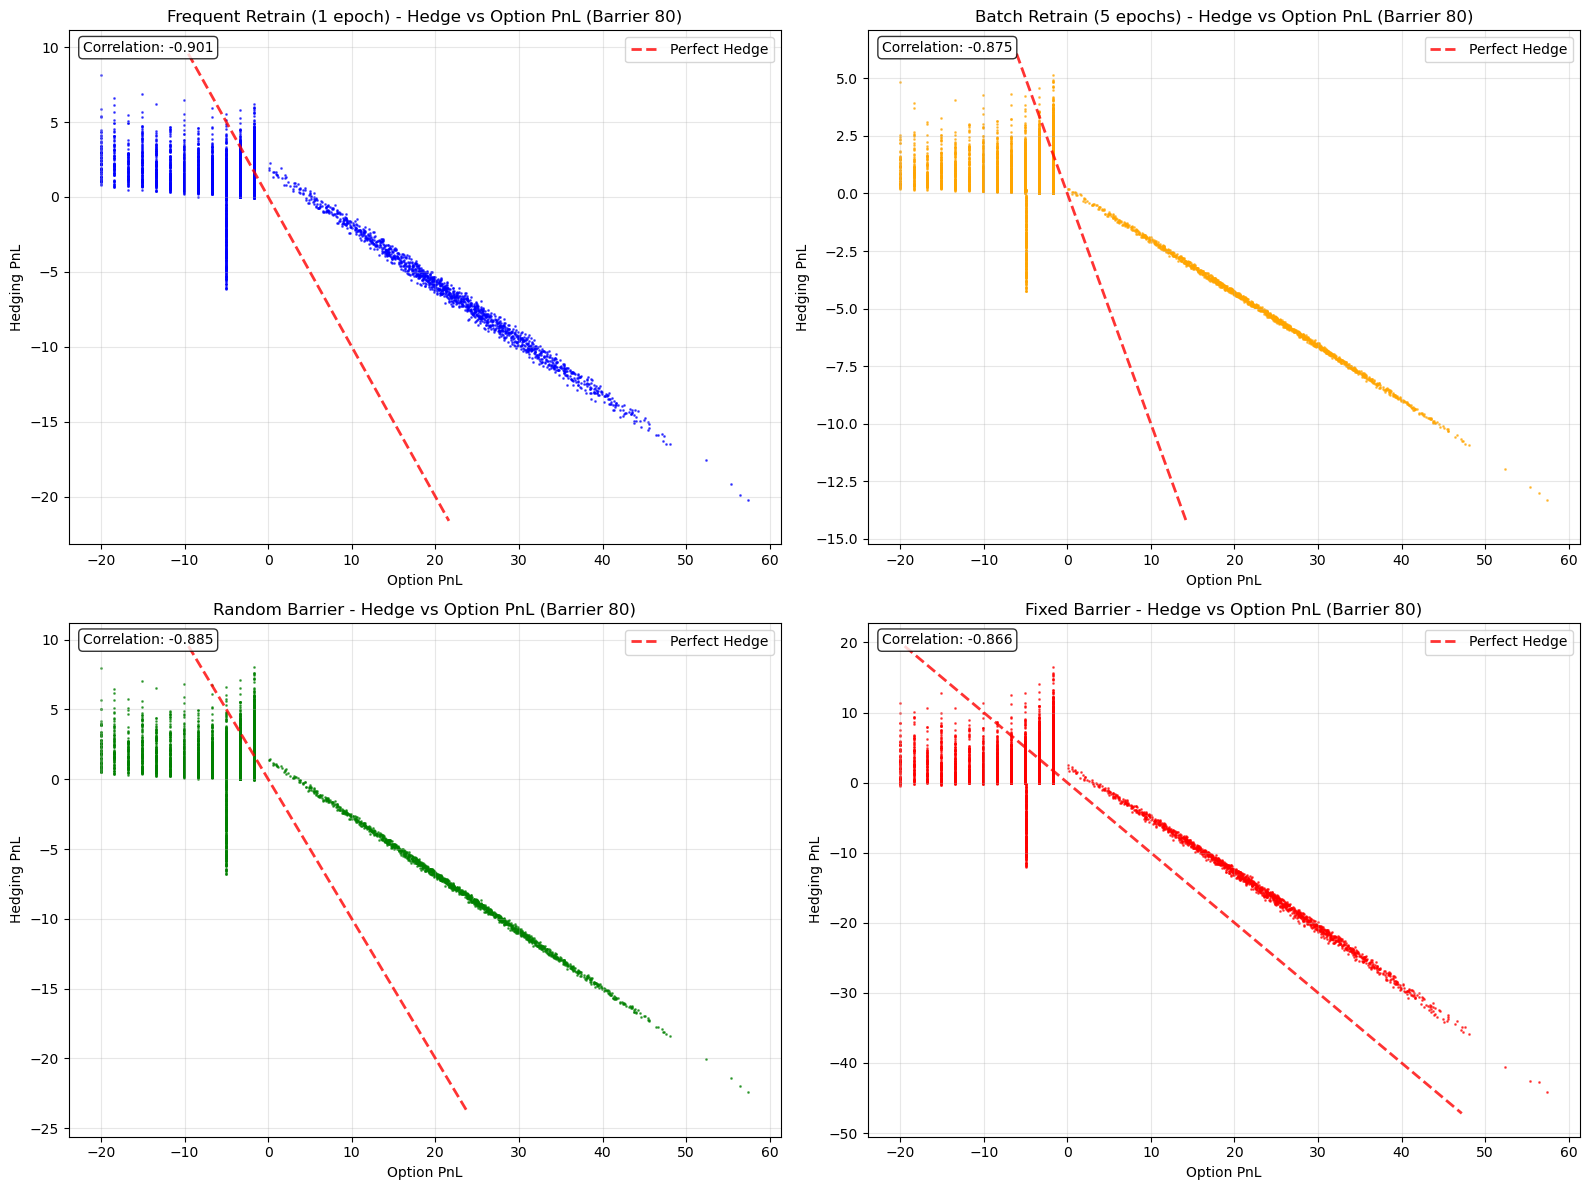

In [6]:
# 只画前4个策略的scatter，避免IndexError
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, name in enumerate(strategy_names[:4]):
    ax = axes[i]
    if (option_pnl_data[80][i] is not None and hedge_pnl_data[80][i] is not None):
        ax.scatter(option_pnl_data[80][i], hedge_pnl_data[80][i],
                  alpha=0.6, s=1, color=colors[i])
        ax.set_xlabel("Option PnL")
        ax.set_ylabel("Hedging PnL")
        ax.set_title(f"{name} - Hedge vs Option PnL (Barrier 80)")
        ax.grid(True, alpha=0.3)
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        pts = np.array([max(x_min, -y_max), min(x_max, -y_min)])
        ax.plot(pts, -pts, 'r--', linewidth=2, alpha=0.8, label='Perfect Hedge')
        ax.legend()
        if len(option_pnl_data[80][i]) > 1:
            corr = np.corrcoef(option_pnl_data[80][i], hedge_pnl_data[80][i])[0, 1]
            ax.text(0.02, 0.98, f'Correlation: {corr:.3f}',
                   transform=ax.transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, f"No data for {name}",
               transform=ax.transAxes, ha='center', va='center')
        ax.set_title(f"{name} - No Data Available")
        ax.set_xlabel("Option PnL")
        ax.set_ylabel("Hedging PnL")
plt.tight_layout()
plt.show()

## Key Insights from Retraining Strategies

### Training Approach Comparison
- **Frequent Retraining**: Provides adaptive learning but may be unstable
- **Batch Retraining**: Balances stability with adaptability
- **Random Barrier**: Offers robust generalization across scenarios
- **Fixed Barrier**: Simple but may lack flexibility for varying conditions

### Historical Data Performance
- **Hedge Adaptability**: How strategies respond to real market movements
- **PnL Stability**: Cumulative performance across the time series
- **Strategy Robustness**: Performance under different market regimes

### Practical Considerations
- **Computational Cost**: Trade-off between training frequency and performance
- **Market Regime Changes**: Need for adaptive training strategies
- **Risk Management**: Real-time monitoring and strategy adjustment

### Implementation Guidelines
- **Training Schedule**: Balance between adaptation and stability
- **Feature Selection**: Importance of robust feature sets
- **Performance Monitoring**: Continuous evaluation of hedge effectiveness

This experiment demonstrates the importance of training strategy selection for real-world implementation of Snowball hedging systems, highlighting the trade-offs between different approaches and their suitability for various market conditions.